 - francois.dorfner@univ-tls3.fr

- question D utiliser np.where(abs(H) > seuil, I, I/H>)  lorsque abs (H) < seuil on prend I sinon  on prend I/H
- question E 1/H donne des zéros il faut simplifier la formule avant de pouvoir l'utiliser Iwiener = conj(H) / abs(H)^2 * I

In [ ]:
%pip install imageio

:::

**Formuler l’équation eq.1 dans le domaine de Fourier, et conclure sur l’effet qu'a $ℎ(𝑥, 𝑦)$ sur la transformée de Fourier de l’image idéale.**   

-  **𝑒𝑞. 1 $\large 𝑖(𝑥, 𝑦) = ℎ(𝑥, 𝑦) ∗ 𝑖_{𝑖𝑑𝑒𝑎𝑙}(𝑥, 𝑦) + 𝑏(𝑥, 𝑦)$** 
- $\normalsize\text{ dans le domaine de Fourier cela donne } \^i(\xi,\eta)= \^h(\xi,\eta) \^i_{ideal}(\xi,\eta)+ \^b (\xi,\eta)$   

    - $\normalsize\text{avec, } \^f(\xi,\eta)= sum_{x=0}^{N-1}\sum_{y=0}^{M-1}f(x,y)\exp^{\large -i2\pi(\frac{\xi}{N}+\frac{\eta*y}{M})}$    

 :::  

In [2]:
# Some usefull library
import matplotlib.pyplot as plt
import scipy.signal
import numpy as np
from scipy.signal import convolve2d
from PIL import Image
import imageio
from matplotlib.pyplot import *

:::
 - Charger l’image *'coat_of_arms.png'* et visualiser la. 
 - Cette image constituera pour la suite $𝑖_{𝑖𝑑𝑒𝑎𝑙}(𝑥, 𝑦)$.   
 - Générer l’image $𝑖(𝑥, 𝑦)$, en considérant $ℎ(𝑥, 𝑦)$ un filtre moyenneur de taille 20x20.  
 - On considérera ici le cas sans bruit $𝑏(𝑥, 𝑦) = 0$.
 - Avec convolve2D la spécification de **boundary='wrap'** indique que la convolution circulaire. 
   - on considère qu'elle est périodique et qu'elle se répète dans le temps.
   - et la paramètre **mode='same'** permet de conserver la taille de l'image.   

:::

 :::
 
 - *$pb_{norm} = ps_{in}$ / SNR* 
   - permet de déterminer la puissance du bruit nécessaire pour atteindre un certain niveau de SNR
   - Un SNR de 20 dB signifie que le signal est très nettement supérieur au bruit, avec un rapport de puissance de 100:1. 
   - Cette valeur indique une qualité de signal très bonne et une faible influence du bruit sur le signal.
   - *Exemple avec $SNR_{DB}$ = 20*
      - Si $SNR_{db}$ =20 db, alors :
      - $SNR =10^{(20/10)}=10^2$
      - Cela signifie que la puissance du signal est 100 fois supérieure à la puissance du bruit.   

::: 

 :::
 - *$ps_{in} =\sum_{n=0}^{n=lgn}\sum_{m=0}^{n=cln}(Conv2DImg^2))/ (Conv2DImg.shape[0]*Conv2DImg.shape[1])$*: 
 
    - Somme les carrés de tous les pixels de l'image. 
    - Somme est appelée 2 fois, pour les lignes et les colonnes, donnant la somme totale des carrés de tous les pixels.
    - On divise ensuite la somme des carrés par le nombre total de pixels pour obtenir la puissance moyenne du signal.
:::
:::
 - *$noisy_{norm} = \sqrt(pb_{norm}) * randn(Conv2DImg.shape[0]*Conv2DImg.shape[1])$*  
     - Calcul de la fonction $\sqrt pb_{norm}$ :
         - Cette fonction calcule la racine carrée de la puissance du bruit (pb_norm). 
         - Elle retourne la racine carrée de la donnée, correspondant à l'écart type du bruit gaussien.
     - Utilisée pour générer et normaliser du bruit additif gaussien pour ajouter à une image. 
     - Normalisation du Bruit: 
        - La multiplication de np.sqrt(pb_norm) par le tableau de nombres aléatoires générés par np.random.randn normalise le bruit pour qu'il ait la puissance spécifiée par pb_norm. Cela signifie que le bruit généré aura une variance égale à pb_norm, ce qui est la puissance du bruit souhaitée.

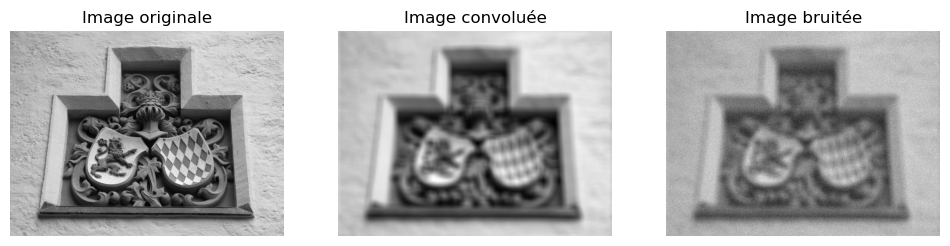

In [8]:
# Charger l'image
img = plt.imread('coat_of_arms.png')
img = np.array(img,np.dtype(float)) # ne pas laisser l'image en UINT8
# Définir la taille du masque
size = 20
grad = np.zeros((img.shape), dtype='float')
# Créer le masque de convolution
kernel = np.ones((size, size)) / (size * size)
h = np.zeros_like(img, dtype='float')

# Recentrer manuellement l'image
center_x, center_y = img.shape[0] // 2, img.shape[1] // 2
start_x, start_y = center_x - kernel.shape[0] // 2, center_y - kernel.shape[1] // 2
end_x, end_y = start_x + kernel.shape[0], start_y + kernel.shape[1]
H[start_x:end_x, start_y:end_y] = kernel
# positionne en haut et à gauche le kernel de convolution 
#H[:kernel.shape[0],:kernel.shape[1]]=kernel

myConv2DImg = convolve2d(img, H, boundary='wrap', mode='same')

# Rapport Signal sur Bruit (SNR)
# Calcul de l'image bruitée
SNR_DB=20
SNR=(10.0**(SNR_DB/10))
ps_in = np.sum(np.sum(myConv2DImg**2))/(myConv2DImg.shape[0]*myConv2DImg.shape[1])
pb_norm = ps_in/SNR
noisy_norm = np.sqrt(pb_norm)*np.random.randn(myConv2DImg.shape[0]*myConv2DImg.shape[1])
noisy_norm = noisy_norm.reshape((img.shape))
Ibruite = myConv2DImg + noisy_norm

# Visualiser l'image originale et l'image filtrée
figure(figsize=(12, 6))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Image originale')
plt.axis('off')

plt.subplot(132)
plt.imshow(myConv2DImg, cmap='gray')
plt.title('Image convoluée')
plt.axis('off')

plt.subplot(133)
plt.imshow(Ibruite, cmap='gray')
plt.title('Image bruitée')
plt.axis('off')

show()        

 **Retrouver $\large 𝑖_{𝑖𝑑𝑒𝑎𝑙(𝑥, 𝑦)}$ :**   
Naïvement on serait tenté d’obtenir la TF à partir du rapport signal sur bruit :$\large \frac{𝐼(𝑢,𝑣)}{𝐻(𝑢,𝑣)}$ (dB). 
Mettez cette méthode en œuvre et commenter le résultat:
La méthode proposé, n'est pas directement applicable pour plusieurs raisons.
Le rapport I(u, v) / H(u, v) ne représente pas directement le SNR pour plusieurs raisons :

- **Puissance vs Amplitude** : Le SNR est basé sur les puissances des signaux, tandis que I(u, v) et H(u, v) représentent les amplitudes dans le domaine de Fourier. Il faudrait prendre les carrés de ces amplitudes pour obtenir les puissances.

- **Intégration sur les Fréquences** : Le SNR est une mesure globale qui intègre les puissances sur toutes les fréquences, alors que I(u, v) / H(u, v) est une opération ponctuelle à chaque fréquence.

- **Phase et Amplitude** : Les transformées de Fourier incluent à la fois l'amplitude et la phase, mais le SNR ne prend en compte que l'amplitude

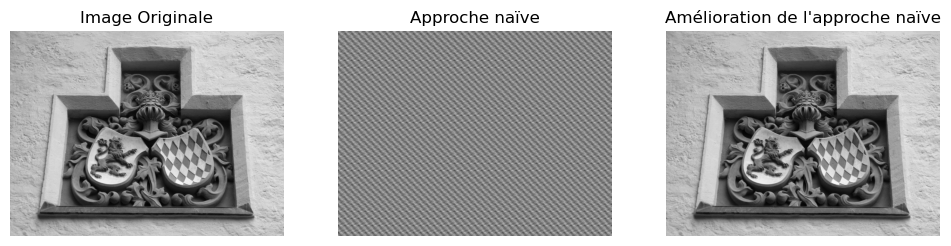

In [10]:
#from PIL import Image
import matplotlib.pyplot as plt

# Appliquer la DFT
fft_img = np.fft.fft2(img)
fft_H = np.fft.fft2(H)
blurred_img = fft_img * fft_H
result_fft_convol = np.real(np.fft.ifft2(blurred_img))

# Calculer la transformée de Fourier de l'image reconstituée

imgIdl_fft = (1/fft_H) * fft_img
result_imgIdl = np.real(np.fft.ifft2(imgIdl_fft))

seuil = 0
modified_fft_img = np.where(np.abs(fft_H) > seuil, fft_img , imgIdl_fft)
result_modified_fft_img = np.real(np.fft.ifft2(modified_fft_img))

# Affichage de l'image et de la région de bruit
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Image Originale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(result_imgIdl, cmap='gray')
plt.title('Approche naïve')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_modified_fft_img, cmap='gray')
plt.title('Amélioration de l\'approche naïve')
plt.axis('off')

plt.show()

**Visualiser la transformée de Fourier de $𝑖_{𝑖𝑑𝑒𝑎𝑙}(𝑥, 𝑦)$, $𝑖(𝑥, 𝑦)$ et $ℎ(𝑥,𝑦).$**
 - Retrouver $𝑖_{𝑖𝑑𝑒𝑎𝑙(𝑥, 𝑦)}$ :
  - Mettez cette méthode en œuvre et commenter le résultat.
  - Commenter les trois résultats : 
  - l'image convoluée avec un filtre moyenneur atténue les contours et floutte l'image.
  - Ajouter un bruit de type l'image bruitée fait disparaitre 

:::
**Transformée de Fourier, décomposition en Fréquences**
 - La **FFT** est un algorithme qui calcule **la Transformée de Fourier Discrète** (DFT) d'un signal, ce qui **décompose le signal en ses composantes fréquentielles**. Cela signifie que la FFT prend un signal dans le **domaine temporel (ou spatial) et le transforme en un spectre de fréquences**, montrant les **amplitudes** et les **phases** des différentes fréquences présentes dans le signal. Le résultat est un array complexe représentant la transformée de Fourier de l'entrée.

 - La **FFTI** est l'opération **inverse de la FFT**, elle **prend le spectre de fréquences** obtenu par la FFT et **le transforme de nouveau en un signal** dans le domaine temporel (ou spatial). Cela permet de reconstruire le signal original à partir de ses composantes fréquentielles.

 - la multiplication élément-wise (point à point) est équivalente à np.mult() et * entre deux matrices de mêmes dimensions. 
 - Dans le domaine de fourrier le produit est un produit d'Admar. 
 
::: 

 :::
 **Padding de l'image**
 - Le padding de l'image est nécessaire pour éviter les effets d'aliasing et garantir que la convolution dans le domaine fréquentiel produise le résultat attendu. Généralement, on ajoute des zéros autour de l'image pour que sa taille soit suffisamment grande pour accueillir le noyau et les bords de l'image.

 - Padding du noyau, le kernel doit également être paddé, mais de manière différente. La taille du noyau paddé doit être la même que la taille de l'image paddée pour que la multiplication dans le domaine fréquentiel soit valide. Cela signifie que l'on ajoute des zéros autour du noyau pour le porter à la même taille que l'image paddée.
:::

:::
Le filtre de Wiener est une méthode plus robuste pour récupérer une estimation de l’image $𝑖_{𝑖𝑑𝑒𝑎𝑙}(𝑥,𝑦)$.
:::

:::
$ 𝑖_{𝑖𝑑𝑒𝑎𝑙}(𝑥,𝑦) = \biggl[ \frac{1}{H(u,v)} \frac{|H(u,v)|^2}{|H(u,v)|^2 + K}\biggr] * I(u,v)\text { avec }|H(u,v)|^2 = H(u,v) * conj(H(u,v)) = \biggl[\frac{conj(H(u,v))}{H(u,v) * conj(H(u,v)) + K}  \biggr]*I(u,v)$ 

:::

:::
Le filtre de Wiener pour $K = 0$ équivaut mathématiquement à la méthode naïve $\large \frac{𝐼(𝑢,𝑣)}{𝐻(𝑢,𝑣)}$ (dB) le résultat diffère mais reste floue.
:::

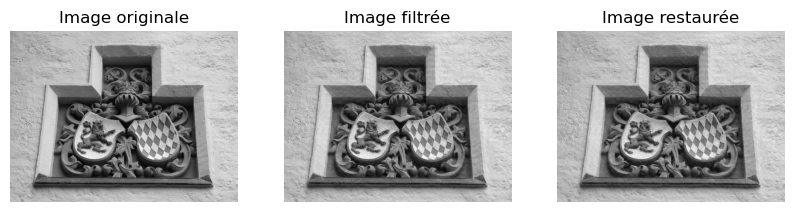

In [129]:
# Appliquer la transformation de Fourier
from scipy.fft import fft
from scipy.ndimage import gaussian_filter

# Première phase 
# Calculons la transformée de Fourier de l'image floue
# La convolution dans le domaine fréquentiel est la multiplication point par point des images (point-wise ou Adamar)
# Recentrer manuellement l'image

img_fft = np.fft.fft2(img)
H_fft = np.fft.fft2(H)

blurred_img = img_fft * H_fft
deconvolved_img_fft = blurred_img / (H_fft + 1e-6)
result_fft_convol = np.real(np.fft.ifft2(deconvolved_img_fft))

# Calculer la transformée de Fourier de l'image reconstituée
#conj_H_fft = np.conj(H_fft) 
conj_H_fft = np.conj(blurred_img) 
# Paramètres pour le filtre de Wiener
sigma_bruit = 0.000001 # Variance du bruit
# Appliquer le filtre de Wiener
wiener_filter = (1/(H_fft * conj_H_fft + sigma_bruit) * conj_H_fft) * blurred_img
# Appliquer la transformée de Fourier inverse
result_restaure = np.real(np.fft.ifft2(wiener_filter))

# Visualiser l'image originale, filtrée et restaurée
plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Image originale'), plt.xticks([]), plt.yticks([])
plt.axis('off')

plt.subplot(132)
plt.imshow(result_fft_convol, cmap='gray')
plt.title('Image filtrée'), plt.xticks([]), plt.yticks([])
plt.axis('off')

plt.subplot(133)
plt.imshow(result_restaure, cmap='gray')
plt.title('Image restaurée'),plt.xticks([]), plt.yticks([])
plt.axis('off')

plt.show()

 - Mêmes questions qu’en 2, mais en considérant le cas avec bruit. 
 - Dans ce cas, l’image obtenue en 2.a sera bruitée avec un bruit additif Gaussien, de puissance telle que le RSB soit de 40 dB. 
 - Dans ce cas avec bruit, la constante K sera choisie plus grande (10e-3).

SNR 47.46116509769615


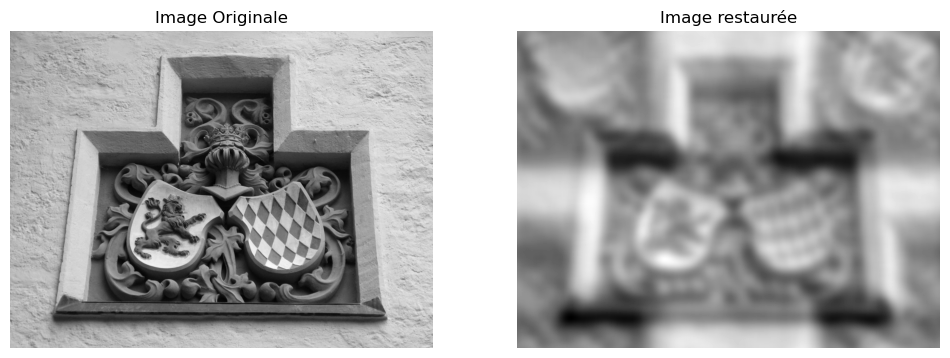

In [213]:
# Transformer l'image en domaine de Fourier
img_fft = np.fft.fft2(img)
H_fft = np.fft.fft2(H)
blurred_img = img_fft * H_fft
#blurred_img = blurred_img / (H_fft + 1e-6)


noise_fft = np.fft.fft2(np.random.randn(*img.shape)* 0.09 )
ps_in = np.sum(np.sum(np.abs(img_fft)**2)) / (img.shape[0] * img.shape[1])
pb_norm = np.sum(np.sum(np.abs(noise_fft)**2)) / (img.shape[0] * img.shape[1])
print(f'SNR {ps_in/pb_norm}')
# Ajouter le bruit à l'image dans le domaine de Fourier
noisy_blurred_img_fft = blurred_img + noise_fft


# Calculer la transformée de Fourier de l'image reconstituée
conj_H_fft = np.conj(H_fft) 
# Paramètres pour le filtre de Wiener
#wiener_filter = (conj_H_fft / (H_fft * conj_H_fft) +(0.001)) * blurred_img
wiener_filter = (conj_H_fft / (np.abs(H_fft)**2 + 1e-6 + ps_in/pb_norm))
restored_img_fft = wiener_filter * noisy_blurred_img_fft
# Appliquer la transformée de Fourier inverse
result_restaure = np.real(np.fft.ifft2(restored_img_fft))

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Image Originale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_restaure, cmap='gray')
plt.title('Image restaurée')
plt.axis('off')

plt.show()